# SugarSense: Early Diabetes Risk Screening with Supervised Machine Learning

## Project Objective

The objective of this project is to develop a supervised machine-learning
classification model that predicts whether a patient is likely to have
diabetes based on eight clinical measurements.

The target variable is `Outcome`:

- `0` → Non-diabetic
- `1` → Diabetic

The project compares six supervised-learning algorithms:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. XGBoost
6. Support Vector Machine (SVM)

Since this is a medical screening problem, missing a diabetic patient is
considered more serious than incorrectly flagging a healthy patient.
Therefore, Recall for the diabetic class and ROC-AUC will be important
evaluation metrics.

This project follows a leakage-safe machine-learning workflow consisting of
data auditing, exploratory data analysis, feature engineering, model
comparison, hyperparameter tuning, final evaluation and threshold tuning.

## Dataset Description

The dataset used in this project is the Pima Indians Diabetes Database.

It contains 768 patient records with eight clinical input features and one
binary target variable.

### Input Features

| Feature | Description |
|---|---|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure |
| SkinThickness | Triceps skin-fold thickness |
| Insulin | 2-hour serum insulin |
| BMI | Body Mass Index |
| DiabetesPedigreeFunction | Diabetes family-history score |
| Age | Age of the patient |

### Target Variable

`Outcome`

- `0` → Non-diabetic
- `1` → Diabetic

The dataset contains patients who are females aged 21 years or above.

In [551]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [552]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("diabetes_screening_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [553]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [554]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [555]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


In [556]:
print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome


In [557]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [558]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [559]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [560]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [561]:
problematic_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_counts = (df[problematic_columns] == 0).sum()

zero_percent = (
    df[problematic_columns].eq(0).mean() * 100
).round(2)

problematic_values = pd.DataFrame({
    "Zero Count": zero_counts,
    "Percentage (%)": zero_percent
})

problematic_values

,Zero Count,Percentage (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [562]:
df.replace(0, np.nan)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,NaN
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,NaN
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63,NaN
764,2.0,122.0,70.0,27.0,NaN,36.8,0.340,27,NaN
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30,NaN
766,1.0,126.0,60.0,NaN,NaN,30.1,0.349,47,1.0


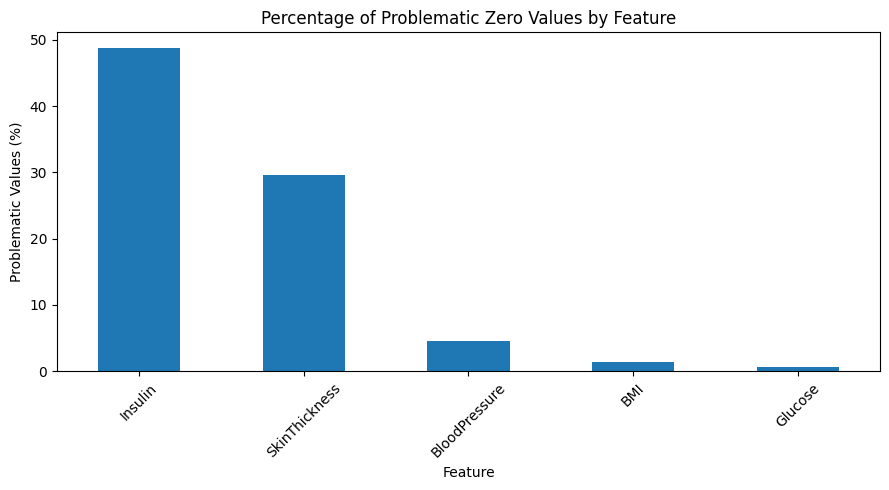

In [563]:
plt.figure(figsize=(9, 5))

zero_percent.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Percentage of Problematic Zero Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Problematic Values (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [564]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [565]:
outcome_counts = df["Outcome"].value_counts()

print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


In [566]:
outcome_percent = (
    df["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(outcome_percent)

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


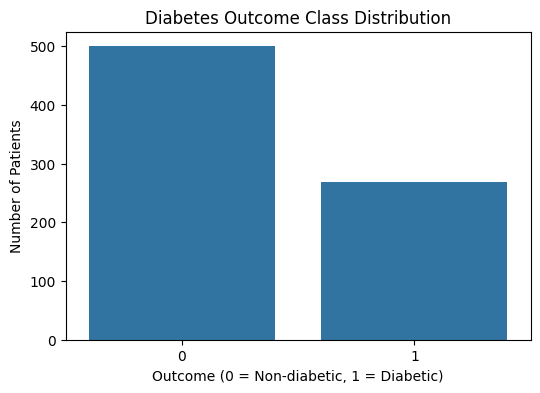

In [567]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Class Distribution")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

In [568]:
df_clean = df.copy()

In [569]:
for column in problematic_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

In [570]:
df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Phase 1 – Data Audit: Findings and Cleaning Strategy

The dataset contains 768 patient records and 9 columns, consisting of
8 clinical input features and one binary target variable.

No explicit missing values were identified using `isnull()`, and there are
no duplicate records. However, the statistical summary revealed zero values
in several clinical measurements where zero is physiologically implausible.

Glucose, BloodPressure, SkinThickness, Insulin and BMI therefore contain
hidden missing values represented by zero. Insulin has the highest proportion
of problematic values at approximately 48.70%, followed by SkinThickness at
approximately 29.56%.

The zero values in these five clinical variables are converted to NaN.
Pregnancies and Outcome are not modified because zero is a valid value for
these variables.

The target variable contains 500 non-diabetic and 268 diabetic patients,
corresponding to approximately 65.1% and 34.9%, respectively. Therefore,
the dataset has moderate class imbalance and accuracy alone will not be
sufficient for evaluating the model.

Missing-value imputation will be performed later inside the machine-learning
pipeline after the train-test split to avoid data leakage.

---

## Phase 1 Complete

The dataset has been audited, problematic zero values have been identified,
class balance has been examined, and the initial cleaning strategy has been
defined.

The cleaned dataframe `df_clean` will be used for the subsequent analysis.

**Next:** Phase 2 – Exploratory Data Analysis (EDA)

# Phase 2 – Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of the
clinical features, compare diabetic and non-diabetic patients, and identify
relationships between the input variables and the diabetes outcome.

The cleaned dataset `df_clean` is used for this analysis.

### 2.1 Feature Distributions by Diabetes Outcome

The distribution of each clinical feature is compared between diabetic and
non-diabetic patients.

These plots help identify differences in feature values between the two
outcome groups and provide an initial understanding of which variables may
be useful for classification.

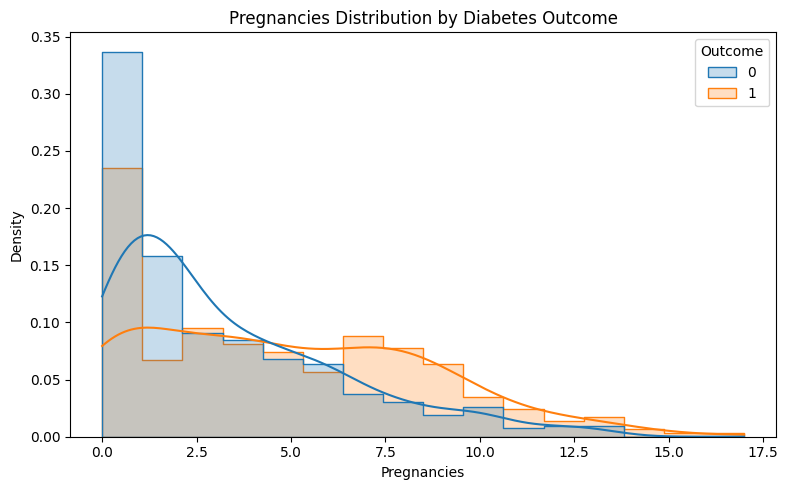

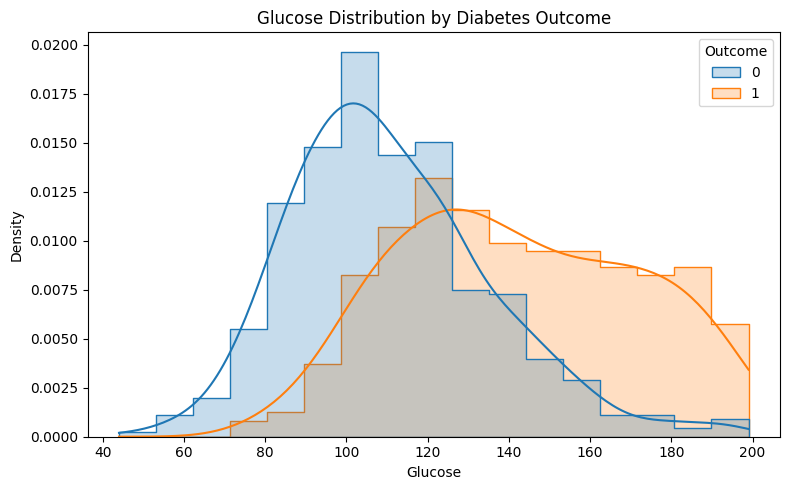

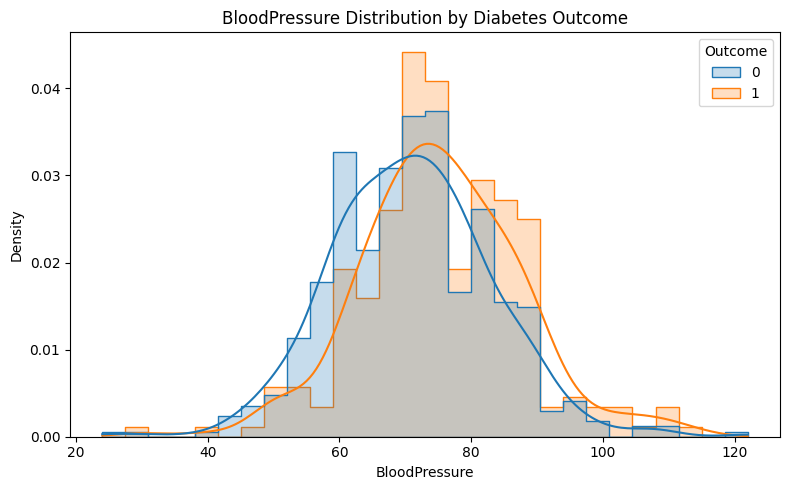

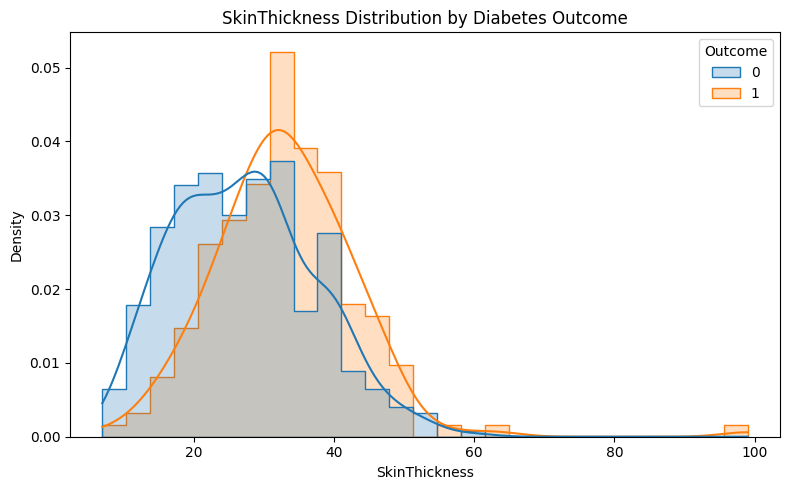

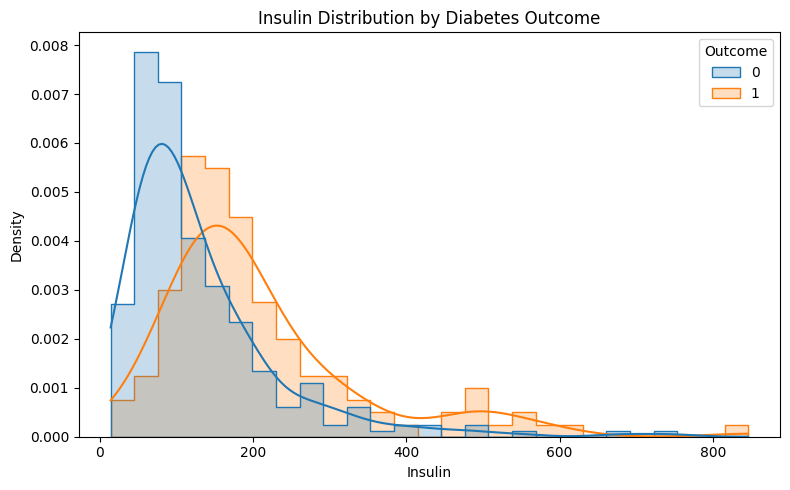

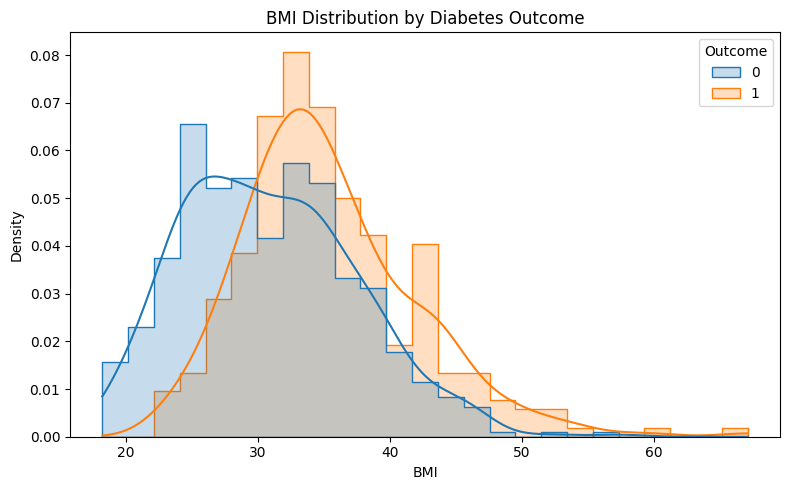

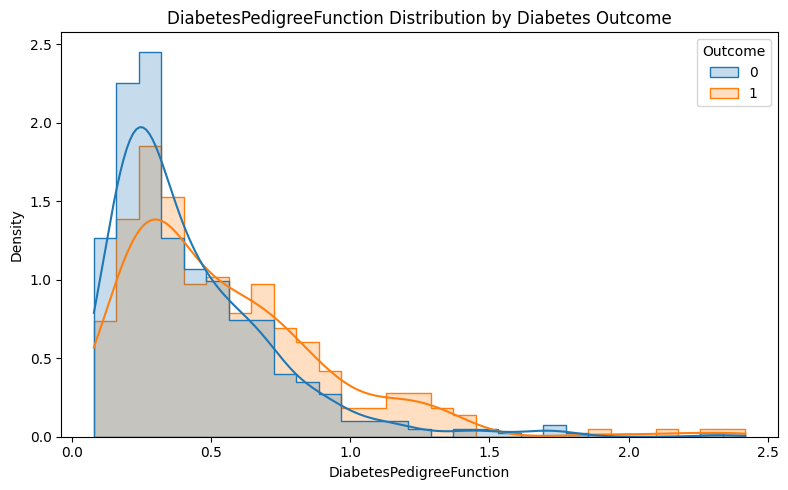

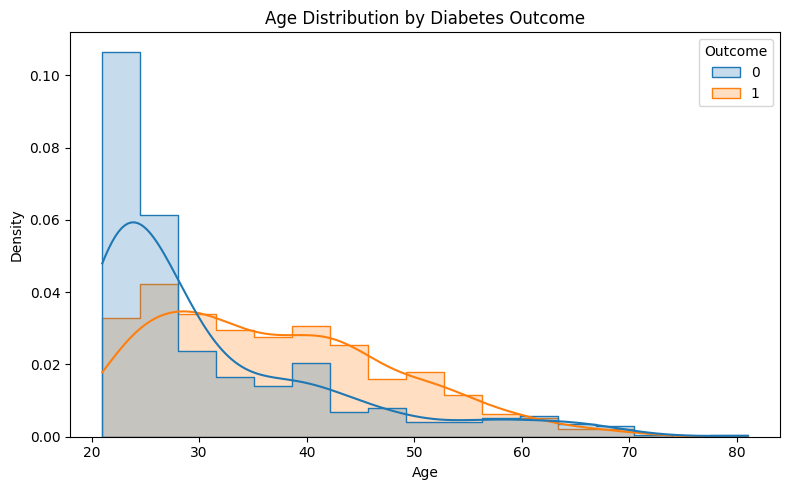

In [571]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for feature in features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df_clean,
        x=feature,
        hue="Outcome",
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{feature} Distribution by Diabetes Outcome")
    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

### 2.2 Correlation Analysis

A correlation heatmap is used to examine the linear relationships among the
clinical features and the diabetes outcome.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak linear relationship.

Correlation does not imply causation. It is used here as an exploratory
analysis to identify potentially useful variables.

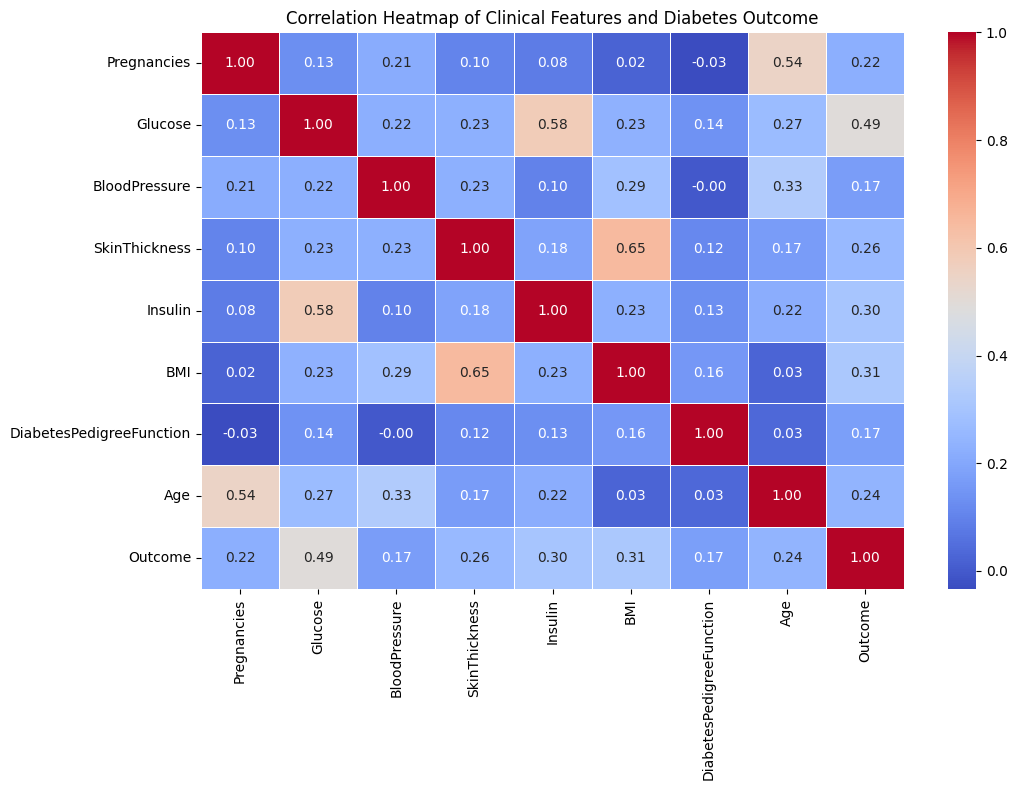

In [572]:
correlation_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Clinical Features and Diabetes Outcome")
plt.tight_layout()
plt.show()

### 2.3 Feature Correlation with Outcome

To identify features that have the strongest linear association with the
diabetes outcome, the correlations with `Outcome` are examined separately.

In [573]:
outcome_correlations = (
    correlation_matrix["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
)

print("Correlation with Outcome:")
print(outcome_correlations)

Correlation with Outcome:
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


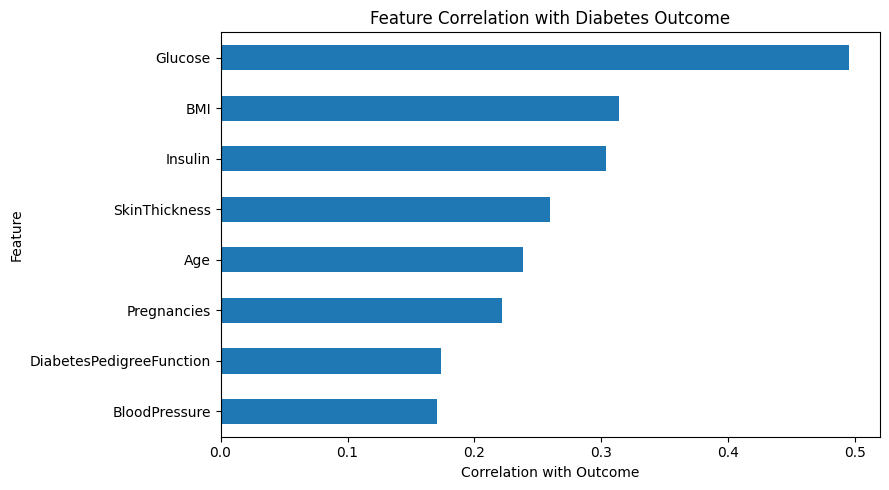

In [574]:
plt.figure(figsize=(9, 5))

outcome_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation with Outcome")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 2.4 Preliminary Feature Assessment

The correlation analysis will be combined with the distribution plots to
identify features that appear useful for distinguishing diabetic and
non-diabetic patients.

Features with relatively stronger relationships with `Outcome` will be
considered potentially useful, while features with correlations close to
zero will be considered weaker linear indicators.

Correlation alone will not be used to remove features because a feature
with weak linear correlation may still provide useful information to a
non-linear machine-learning model.

### 2.5 EDA Observations

1. Glucose shows one of the clearest differences between diabetic and
   non-diabetic patients, with diabetic patients generally showing higher
   glucose values.

2. BMI also shows a noticeable difference between the two outcome groups,
   although there is considerable overlap between them.

3. Age and Pregnancies show a positive association with diabetes outcome,
   with diabetic patients generally tending to have higher values.

4. DiabetesPedigreeFunction shows a weaker positive relationship with the
   outcome compared with Glucose, but it may still provide useful information
   to a machine-learning model.

5. BloodPressure, SkinThickness and Insulin show relatively weak linear
   correlations with the outcome and substantial overlap between the two
   groups. However, they are retained because weak correlation does not mean
   that a feature has no predictive value, particularly for nonlinear models.

## Phase 2 Complete

The exploratory analysis compared the distributions of all eight clinical
features between diabetic and non-diabetic patients.

Glucose showed the clearest separation between the two outcome groups,
while BMI, Age and Pregnancies also showed useful differences. Several
features, including BloodPressure, SkinThickness and Insulin, showed weaker
linear relationships with the target and considerable overlap.

The correlation analysis provides useful initial insights, but correlation
alone is not sufficient for feature selection because machine-learning
models may capture nonlinear relationships.

The findings from EDA will guide the feature-engineering decisions in Phase 3.

# Phase 3 — Feature Engineering

In this phase, clinically meaningful and model-useful features are engineered from the original variables.

The objective is to capture nonlinear relationships and interactions that may not be fully represented by the raw features.

The target variable `Outcome` is not used during feature engineering to prevent data leakage.

In [575]:
# Create a copy of the cleaned dataset
df_fe = df_clean.copy()

# Display the current columns
print("Original columns:")
print(df_fe.columns.tolist())

print("\nShape:", df_fe.shape)

Original columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Shape: (768, 9)


### 3.1 BMI Category

BMI is converted into clinically meaningful categories.

- Underweight: BMI < 18.5
- Normal: 18.5–24.9
- Overweight: 25–29.9
- Obese: BMI ≥ 30

In [576]:
df_fe["BMI_Category"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    right=False
)

df_fe["BMI_Category"].value_counts()

,count
BMI_Category,
Obese,472
Overweight,179
Normal,102
Underweight,4


### 3.2 Age Group

Age is grouped into meaningful ranges to capture potential differences in diabetes risk across life stages.

In [577]:
df_fe["Age_Group"] = pd.cut(
    df_fe["Age"],
    bins=[0, 30, 45, 60, float("inf")],
    labels=["Young", "Middle_Aged", "Older", "Senior"],
    right=False
)

df_fe["Age_Group"].value_counts()

,count
Age_Group,
Young,396
Middle_Aged,239
Older,101
Senior,32


### 3.3 Glucose-BMI Interaction

Glucose level and BMI can jointly contribute to diabetes risk.

An interaction feature is created to allow machine-learning models to capture this combined effect.

In [578]:
df_fe["Glucose_BMI_Interaction"] = (
    df_fe["Glucose"] * df_fe["BMI"]
)

df_fe["Glucose_BMI_Interaction"].describe()

,Glucose_BMI_Interaction
count,752.000000
mean,4006.858378
std,1480.170183
min,1100.000000
25%,2924.100000
50%,3773.450000
75%,4841.775000
max,10692.000000


### 3.4 Glucose-Age Interaction

The relationship between blood glucose and diabetes risk can vary with age.

Therefore, an interaction between glucose level and age is introduced.

In [579]:
df_fe["Glucose_Age_Interaction"] = (
    df_fe["Glucose"] * df_fe["Age"]
)

df_fe["Glucose_Age_Interaction"].describe()

,Glucose_Age_Interaction
count,763.000000
mean,4144.577982
std,2084.837749
min,1232.000000
25%,2621.500000
50%,3480.000000
75%,5167.500000
max,12998.000000


### 3.5 Metabolic Risk Score

A composite metabolic risk score is created using glucose, BMI, age and blood pressure.

The score is intended as an exploratory engineered feature rather than a clinical diagnostic measure.

In [580]:
df_fe["Metabolic_Risk_Score"] = (
    (df_fe["Glucose"] / df_fe["Glucose"].max()) +
    (df_fe["BMI"] / df_fe["BMI"].max()) +
    (df_fe["Age"] / df_fe["Age"].max()) +
    (df_fe["BloodPressure"] / df_fe["BloodPressure"].max())
)

df_fe["Metabolic_Risk_Score"].describe()

,Metabolic_Risk_Score
count,724.000000
mean,2.101523
std,0.328511
min,1.317524
25%,1.849801
50%,2.068106
75%,2.340035
max,3.104205


### 3.6 Feature Engineering Summary

In [581]:
print("Dataset shape after feature engineering:")
print(df_fe.shape)

print("\nColumns:")
for col in df_fe.columns:
    print(col)

Dataset shape after feature engineering:
(768, 14)

Columns:
Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age
Outcome
BMI_Category
Age_Group
Glucose_BMI_Interaction
Glucose_Age_Interaction
Metabolic_Risk_Score


In [582]:
df_fe.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_BMI_Interaction,Glucose_Age_Interaction,Metabolic_Risk_Score
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Obese,Older,4972.8,7400.0,2.451912
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Overweight,Middle_Aged,2261.0,2635.0,1.747259
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Normal,Middle_Aged,4263.9,5856.0,2.186493
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young,2500.9,1869.0,1.666257
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Middle_Aged,5904.7,4521.0,2.066043


In [583]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   763 non-null    float64 
 2   BloodPressure             733 non-null    float64 
 3   SkinThickness             541 non-null    float64 
 4   Insulin                   394 non-null    float64 
 5   BMI                       757 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   BMI_Category              757 non-null    category
 10  Age_Group                 768 non-null    category
 11  Glucose_BMI_Interaction   752 non-null    float64 
 12  Glucose_Age_Interaction   763 non-null    float64 
 13  Metabolic_Risk_Score      724 non-null    float64 

### 3.7 Validate Engineered Features

The engineered features are inspected to verify their distributions, missing values, and relationship with the diabetes outcome.

In [584]:
# Check missing values in engineered features
print("Missing values:")
print(df_fe.isnull().sum())

print("\n" + "="*50)

# Check engineered feature statistics
print("Engineered feature statistics:")
display(
    df_fe[
        [
            "Glucose_BMI_Interaction",
            "Glucose_Age_Interaction",
            "Metabolic_Risk_Score"
        ]
    ].describe()
)

Missing values:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                 11
Age_Group                     0
Glucose_BMI_Interaction      16
Glucose_Age_Interaction       5
Metabolic_Risk_Score         44
dtype: int64

Engineered feature statistics:


,Glucose_BMI_Interaction,Glucose_Age_Interaction,Metabolic_Risk_Score
count,752.000000,763.000000,724.000000
mean,4006.858378,4144.577982,2.101523
std,1480.170183,2084.837749,0.328511
min,1100.000000,1232.000000,1.317524
25%,2924.100000,2621.500000,1.849801
50%,3773.450000,3480.000000,2.068106
75%,4841.775000,5167.500000,2.340035
max,10692.000000,12998.000000,3.104205


In [585]:
# Check categorical feature distributions
print("BMI Category:")
print(df_fe["BMI_Category"].value_counts(dropna=False))

print("\nAge Group:")
print(df_fe["Age_Group"].value_counts(dropna=False))

BMI Category:
BMI_Category
Obese          472
Overweight     179
Normal         102
NaN             11
Underweight      4
Name: count, dtype: int64

Age Group:
Age_Group
Young          396
Middle_Aged    239
Older          101
Senior          32
Name: count, dtype: int64


In [586]:
# Final Phase 3 dataset preview
display(df_fe.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_BMI_Interaction,Glucose_Age_Interaction,Metabolic_Risk_Score
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,Obese,Older,4972.8,7400.0,2.451912
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,Overweight,Middle_Aged,2261.0,2635.0,1.747259
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,Normal,Middle_Aged,4263.9,5856.0,2.186493
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young,2500.9,1869.0,1.666257
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Middle_Aged,5904.7,4521.0,2.066043


### 3.8 Correlation Analysis of Engineered Features

The correlation between the engineered numerical features and the diabetes outcome is examined to understand whether the newly created features contain useful predictive information.

In [587]:
# Correlation of engineered numerical features with Outcome

engineered_features = [
    "Glucose_BMI_Interaction",
    "Glucose_Age_Interaction",
    "Metabolic_Risk_Score"
]

correlation = df_fe[engineered_features + ["Outcome"]].corr()

display(correlation["Outcome"].sort_values(ascending=False))

,Outcome
Outcome,1.000000
Glucose_BMI_Interaction,0.519287
Metabolic_Risk_Score,0.483433
Glucose_Age_Interaction,0.409236


### 3.9 Distribution of Engineered Features

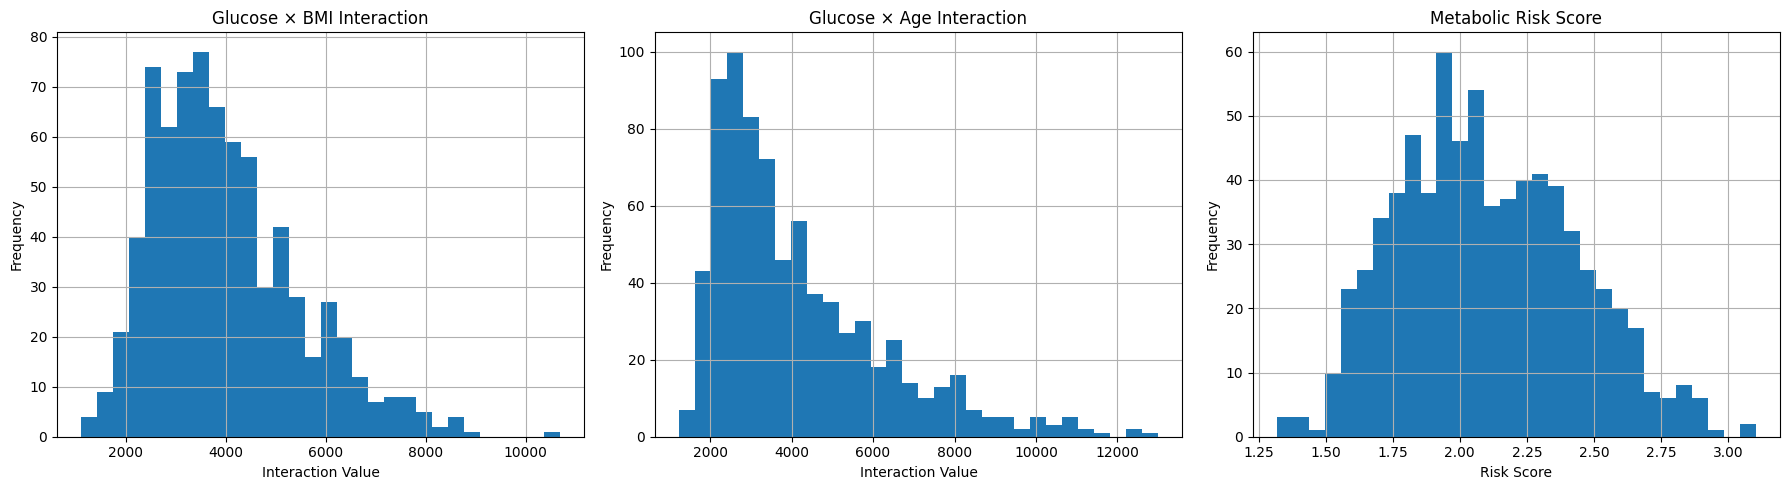

In [588]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_fe["Glucose_BMI_Interaction"].hist(ax=axes[0], bins=30)
axes[0].set_title("Glucose × BMI Interaction")
axes[0].set_xlabel("Interaction Value")
axes[0].set_ylabel("Frequency")

df_fe["Glucose_Age_Interaction"].hist(ax=axes[1], bins=30)
axes[1].set_title("Glucose × Age Interaction")
axes[1].set_xlabel("Interaction Value")
axes[1].set_ylabel("Frequency")

df_fe["Metabolic_Risk_Score"].hist(ax=axes[2], bins=30)
axes[2].set_title("Metabolic Risk Score")
axes[2].set_xlabel("Risk Score")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 3.10 Save Feature-Engineered Dataset

In [589]:
# Save the feature-engineered dataset

df_fe.to_csv(
    "diabetes_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved successfully.")
print("File: diabetes_feature_engineered.csv")

Feature-engineered dataset saved successfully.
File: diabetes_feature_engineered.csv


In [590]:
import os

print(os.path.exists("diabetes_feature_engineered.csv"))
print(os.path.getsize("diabetes_feature_engineered.csv"), "bytes")

True
65727 bytes


# Phase 4 — Machine Learning Pipeline

In this phase, the processed diabetes dataset is converted into a machine learning-ready format.

The workflow includes:
1. Defining features and target
2. Train-test splitting
3. Identifying numerical and categorical features
4. Building preprocessing pipelines
5. Handling missing values
6. Encoding categorical variables
7. Scaling numerical variables
8. Training baseline machine learning models
9. Evaluating model performance

In [591]:
# Machine Learning Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


In [592]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 4.1 Define Features and Target

The `Outcome` column represents the target variable.

- `X` contains the input features.
- `y` contains the target variable.

In [593]:
# Define features and target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [594]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


In [595]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## 4.2 Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to train the models, while the test set is used to evaluate their performance on unseen data.

In [596]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


## 4.3 Identify Feature Types

Numerical features will be imputed and standardized.

Categorical features will be imputed and one-hot encoded.

In [597]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Categorical features:
[]


## 4.4 Numerical Preprocessing Pipeline

The numerical preprocessing pipeline performs two operations:

1. Missing-value imputation using the median
2. Feature scaling using StandardScaler

In [598]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [599]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [600]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 4.5 Baseline Machine Learning Models

Three baseline classification algorithms are trained:

- Logistic Regression
- Decision Tree
- Random Forest

The same preprocessing pipeline is applied to each model to ensure a fair comparison.

In [601]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [602]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [603]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [604]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [605]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [606]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [607]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [608]:
y_pred_lr = logistic_pipeline.predict(X_test)
y_pred_dt = decision_tree_pipeline.predict(X_test)
y_pred_rf = random_forest_pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [609]:
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully.")

Prediction probabilities generated successfully.


In [610]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

In [611]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
1,Decision Tree,0.720779,0.634146,0.481481,0.547368,0.665741
2,Random Forest,0.746753,0.653061,0.592593,0.621359,0.814630


In [612]:
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
1,Random Forest,0.746753,0.653061,0.592593,0.621359,0.814630
2,Decision Tree,0.720779,0.634146,0.481481,0.547368,0.665741


In [613]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [614]:
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       100
           1       0.63      0.48      0.55        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154



In [615]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



In [616]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

Logistic Regression Confusion Matrix:
[[82 18]
 [26 28]]


In [617]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Decision Tree:")
print(cm_dt)

print("\nRandom Forest:")
print(cm_rf)

Decision Tree:
[[85 15]
 [28 26]]

Random Forest:
[[83 17]
 [22 32]]


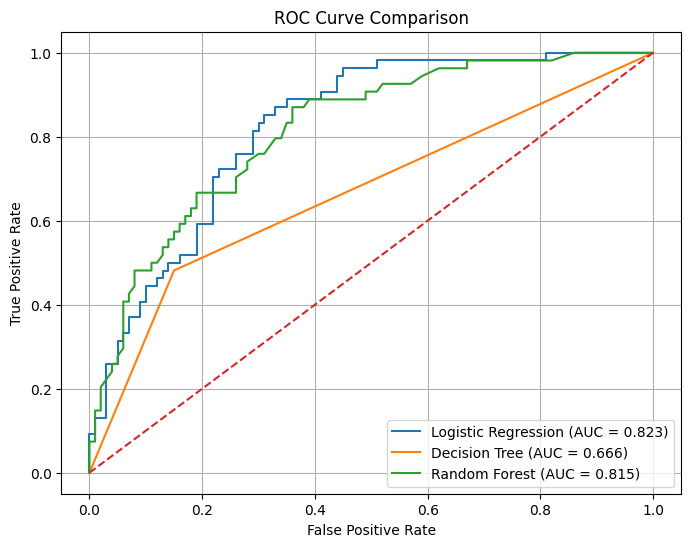

In [618]:
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()
plt.show()

# Phase 5 — Model Comparison

In this phase, all six supervised learning algorithms are compared using
5-fold stratified cross-validation.

The models are:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. XGBoost
6. Support Vector Machine (SVM)

Cross-validation is used instead of the test set so that the test data remains
untouched until Phase 7.

The main evaluation metrics are Accuracy, Precision, Recall, F1-score and
ROC-AUC. Since this is a medical screening problem, Recall and ROC-AUC are
especially important.

In [619]:
from sklearn.model_selection import StratifiedKFold, cross_validate

### 5.2 Stratified 5-Fold Cross-Validation

Stratified cross-validation maintains approximately the same proportion of
diabetic and non-diabetic patients in every fold.

Five folds are used as required by the project instructions.

In [620]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

### 5.3 Evaluation Metrics

The models will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Both the mean and standard deviation across the five validation folds will be
reported.

In [621]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

scoring

{'accuracy': 'accuracy',
 'precision': 'precision',
 'recall': 'recall',
 'f1': 'f1',
 'roc_auc': 'roc_auc'}

In [622]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [623]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ])
}

In [624]:
models.keys()

dict_keys(['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM'])

### 5.5 Cross-Validation of All Six Models

Each model is evaluated using the same training data and the same 5-fold
stratified cross-validation strategy.

The test set is not used in this phase.

In [625]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "Train Accuracy": scores["train_accuracy"].mean(),

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Train Accuracy,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.763843,0.758923,0.015644,0.636241,0.029929,0.729014,0.047593,0.677941,0.019378,0.834781,0.033241
1,KNN,0.814747,0.736146,0.016090,0.652145,0.053970,0.542414,0.061153,0.587642,0.026642,0.782350,0.033701
2,Decision Tree,1.000000,0.654698,0.030519,0.505858,0.047296,0.491030,0.062132,0.496815,0.047749,0.616765,0.033416
3,Random Forest,1.000000,0.755698,0.024131,0.688111,0.056887,0.556146,0.018864,0.614074,0.027122,0.813375,0.026067
4,XGBoost,1.000000,0.736132,0.019966,0.638788,0.047838,0.575083,0.033887,0.603215,0.017899,0.773217,0.019156
5,SVM,0.818805,0.737732,0.027954,0.607491,0.046463,0.729014,0.037413,0.660326,0.018245,0.837283,0.026444


### 5.6 Overfitting Analysis

The overfit gap is calculated as:

Overfit Gap = Training Score − Validation Score

A large positive gap can indicate that a model performs substantially better
on the training data than on unseen validation folds.

A smaller gap generally indicates more stable generalization.

In [626]:
cv_results_df["Overfit Gap"] = (
    cv_results_df["Train Accuracy"]
    - cv_results_df["Accuracy Mean"]
)

cv_results_df

,Model,Train Accuracy,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std,Overfit Gap
0,Logistic Regression,0.763843,0.758923,0.015644,0.636241,0.029929,0.729014,0.047593,0.677941,0.019378,0.834781,0.033241,0.004920
1,KNN,0.814747,0.736146,0.016090,0.652145,0.053970,0.542414,0.061153,0.587642,0.026642,0.782350,0.033701,0.078601
2,Decision Tree,1.000000,0.654698,0.030519,0.505858,0.047296,0.491030,0.062132,0.496815,0.047749,0.616765,0.033416,0.345302
3,Random Forest,1.000000,0.755698,0.024131,0.688111,0.056887,0.556146,0.018864,0.614074,0.027122,0.813375,0.026067,0.244302
4,XGBoost,1.000000,0.736132,0.019966,0.638788,0.047838,0.575083,0.033887,0.603215,0.017899,0.773217,0.019156,0.263868
5,SVM,0.818805,0.737732,0.027954,0.607491,0.046463,0.729014,0.037413,0.660326,0.018245,0.837283,0.026444,0.081074


In [627]:
comparison_table = cv_results_df[
    [
        "Model",
        "Accuracy Mean",
        "Accuracy Std",
        "Precision Mean",
        "Precision Std",
        "Recall Mean",
        "Recall Std",
        "F1 Mean",
        "F1 Std",
        "ROC-AUC Mean",
        "ROC-AUC Std",
        "Train Accuracy",
        "Overfit Gap"
    ]
].copy()

comparison_table.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std,Train Accuracy,Overfit Gap
0,Logistic Regression,0.7589,0.0156,0.6362,0.0299,0.7290,0.0476,0.6779,0.0194,0.8348,0.0332,0.7638,0.0049
1,KNN,0.7361,0.0161,0.6521,0.0540,0.5424,0.0612,0.5876,0.0266,0.7824,0.0337,0.8147,0.0786
2,Decision Tree,0.6547,0.0305,0.5059,0.0473,0.4910,0.0621,0.4968,0.0477,0.6168,0.0334,1.0000,0.3453
3,Random Forest,0.7557,0.0241,0.6881,0.0569,0.5561,0.0189,0.6141,0.0271,0.8134,0.0261,1.0000,0.2443
4,XGBoost,0.7361,0.0200,0.6388,0.0478,0.5751,0.0339,0.6032,0.0179,0.7732,0.0192,1.0000,0.2639
5,SVM,0.7377,0.0280,0.6075,0.0465,0.7290,0.0374,0.6603,0.0182,0.8373,0.0264,0.8188,0.0811


### 5.8 Model Performance Comparison

The mean cross-validation scores of the six models are compared using
Accuracy, Precision, Recall, F1-score and ROC-AUC.

The comparison is based only on the training data through 5-fold
stratified cross-validation. The test set remains untouched.

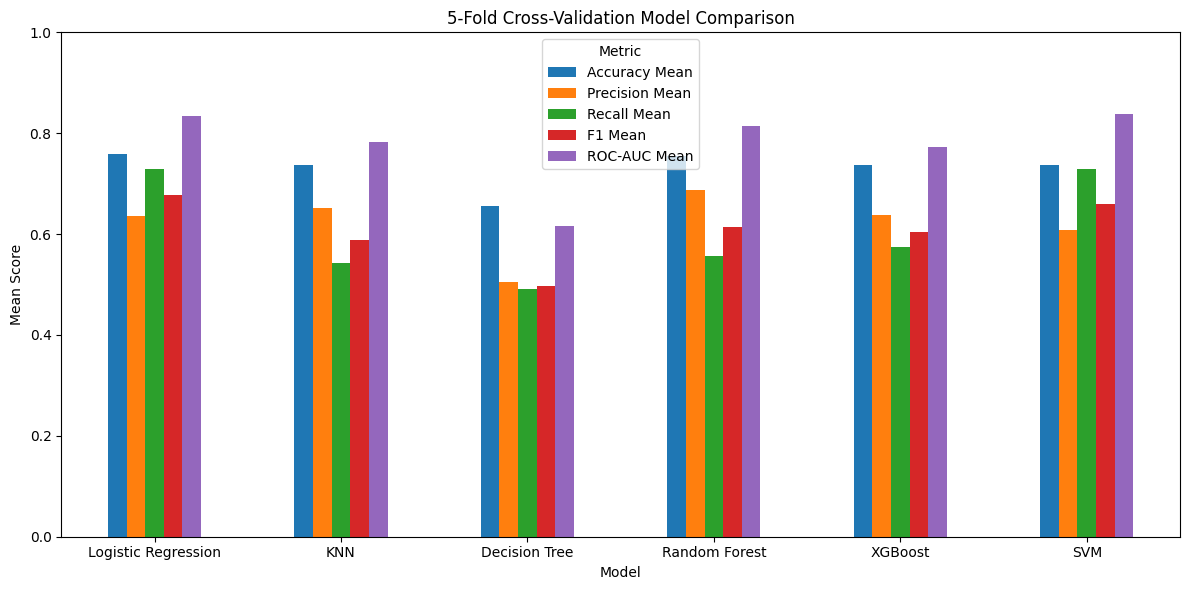

In [628]:
metrics_to_plot = [
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean",
    "ROC-AUC Mean"
]

comparison_table.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("5-Fold Cross-Validation Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 5.9 Overfitting and Stability Analysis

The overfit gap is the difference between the training score and the
cross-validation validation score.

A small gap indicates that the model's training and validation performance
are relatively close, suggesting better stability.

A large positive gap indicates that the model performs much better on the
training data than on validation data, which may indicate overfitting.

In [629]:
overfit_analysis = comparison_table[
    ["Model", "Train Accuracy", "Accuracy Mean", "Overfit Gap"]
].sort_values(
    by="Overfit Gap",
    ascending=False
)

overfit_analysis.round(4)

,Model,Train Accuracy,Accuracy Mean,Overfit Gap
2,Decision Tree,1.0000,0.6547,0.3453
4,XGBoost,1.0000,0.7361,0.2639
3,Random Forest,1.0000,0.7557,0.2443
5,SVM,0.8188,0.7377,0.0811
1,KNN,0.8147,0.7361,0.0786
0,Logistic Regression,0.7638,0.7589,0.0049


### 5.10 Best Model Based on Cross-Validation

The models are ranked using their mean ROC-AUC obtained from 5-fold
stratified cross-validation.

ROC-AUC is used as the primary comparison metric because it measures the
model's ability to distinguish between diabetic and non-diabetic patients
across classification thresholds.

Recall is also important because missing a diabetic patient is considered
more harmful than raising a false alarm.

In [630]:
cv_ranking = comparison_table.sort_values(
    by="ROC-AUC Mean",
    ascending=False
).reset_index(drop=True)

cv_ranking[
    [
        "Model",
        "ROC-AUC Mean",
        "ROC-AUC Std",
        "Recall Mean",
        "Recall Std",
        "Overfit Gap"
    ]
].round(4)

,Model,ROC-AUC Mean,ROC-AUC Std,Recall Mean,Recall Std,Overfit Gap
0,SVM,0.8373,0.0264,0.7290,0.0374,0.0811
1,Logistic Regression,0.8348,0.0332,0.7290,0.0476,0.0049
2,Random Forest,0.8134,0.0261,0.5561,0.0189,0.2443
3,KNN,0.7824,0.0337,0.5424,0.0612,0.0786
4,XGBoost,0.7732,0.0192,0.5751,0.0339,0.2639
5,Decision Tree,0.6168,0.0334,0.4910,0.0621,0.3453


In [631]:
cv_results_df.to_csv(
    "phase5_cv_results.csv",
    index=False
)

print("Phase 5 CV results saved successfully.")

Phase 5 CV results saved successfully.


# Phase 6 — Hyperparameter Tuning

In this phase, the most promising models from Phase 5 are tuned using
RandomizedSearchCV.

The tuning process uses:
- 5-fold stratified cross-validation
- ROC-AUC as the scoring metric
- Random state = 42
- Training data only

The test set will not be used during tuning. It will be kept untouched
until Phase 7 for final evaluation.

The models selected for tuning are:
1. Support Vector Machine (SVM)
2. Logistic Regression
3. Random Forest

In [632]:
from sklearn.model_selection import RandomizedSearchCV

In [633]:
from sklearn.model_selection import StratifiedKFold

cv_tuning = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_tuning

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [634]:
svm_param_dist = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

svm_param_dist

{'model__C': [0.01, 0.1, 1, 10, 100],
 'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
 'model__kernel': ['rbf', 'linear']}

In [635]:
[name for name in globals() if "svm" in name.lower()]

['svm_param_dist', 'svm_pipeline', 'svm_random', 'baseline_svm_score']

In [636]:
[name for name in globals() if "pipeline" in name.lower()]

['Pipeline',
 'numerical_pipeline',
 'categorical_pipeline',
 'logistic_pipeline',
 'decision_tree_pipeline',
 'random_forest_pipeline',
 'svm_pipeline']

In [637]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

svm_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('model', SVC(probability=True, random_state=42))])

In [638]:
svm_param_dist

{'model__C': [0.01, 0.1, 1, 10, 100],
 'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
 'model__kernel': ['rbf', 'linear']}

In [639]:
svm_random = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    refit=True
)

svm_random.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Pregnancies',
                                                                                'Glucose',
                                                                                'BloodPressure',
                                                                                'SkinThickness',
                                                                                'Insulin',
                                                                                'BMI',
                                                                                'DiabetesPedigreeFunction'...
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               [])])),
                                             ('model',
                                              SVC(probability=True,
                                                  random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__C': [0.01, 0.1, 1, 10, 100],
                                        'model__gamma': ['scale', 'auto', 0.001,
                                                         0.01, 0.1, 1],
                                        'model__kernel': ['rbf', 'linear']},
                   random_state=42, scoring='roc_auc')

In [640]:
print("Best SVM Parameters:")
print(svm_random.best_params_)

print("\nBest SVM ROC-AUC:")
print(svm_random.best_score_)

Best SVM Parameters:
{'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.1}

Best SVM ROC-AUC:
0.8351148947951271


## 6.2 Hyperparameter Tuning — Logistic Regression

Logistic Regression is tuned using RandomizedSearchCV with ROC-AUC as the
scoring metric.

The search is performed only on the training data using 5-fold stratified
cross-validation. The test set remains untouched.

In [641]:
logistic_param_dist = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"],
    "model__max_iter": [500, 1000, 2000]
}

logistic_param_dist

{'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
 'model__solver': ['lbfgs'],
 'model__max_iter': [500, 1000, 2000]}

In [642]:
logistic_random = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    refit=True
)

logistic_random.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Pregnancies',
                                                                                'Glucose',
                                                                                'BloodPressure',
                                                                                'SkinThickness',
                                                                                'Insulin',
                                                                                'BMI',
                                                                                'DiabetesPedigreeFunction'...
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               [])])),
                                             ('model',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                                        'model__max_iter': [500, 1000, 2000],
                                        'model__solver': ['lbfgs']},
                   random_state=42, scoring='roc_auc')

In [643]:
print("Best Logistic Regression Parameters:")
print(logistic_random.best_params_)

print("\nBest Logistic Regression ROC-AUC:")
print(logistic_random.best_score_)

Best Logistic Regression Parameters:
{'model__solver': 'lbfgs', 'model__max_iter': 2000, 'model__C': 0.1}

Best Logistic Regression ROC-AUC:
0.8353156146179403


## 6.3 Hyperparameter Tuning — Random Forest

Random Forest is tuned using RandomizedSearchCV to investigate whether
controlling tree depth, minimum samples and the number of trees can improve
validation performance and reduce overfitting.

ROC-AUC is used as the scoring metric, with 5-fold stratified
cross-validation on the training data only.

In [644]:
random_forest_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

random_forest_param_dist

{'model__n_estimators': [100, 200, 300, 500],
 'model__max_depth': [None, 3, 5, 7, 10, 15],
 'model__min_samples_split': [2, 5, 10, 20],
 'model__min_samples_leaf': [1, 2, 4, 8],
 'model__max_features': ['sqrt', 'log2', None]}

In [645]:
random_forest_random = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_forest_random.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Pregnancies',
                                                                                'Glucose',
                                                                                'BloodPressure',
                                                                                'SkinThickness',
                                                                                'Insulin',
                                                                                'BMI',
                                                                                'DiabetesPedigreeFunction'...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               [])])),
                                             ('model',
                                              RandomForestClassifier(n_estimators=200,
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 3, 5, 7, 10,
                                                             15],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='roc_auc')

In [646]:
print("Best Random Forest Parameters:")
print(random_forest_random.best_params_)

print("\nBest Random Forest ROC-AUC:")
print(random_forest_random.best_score_)

Best Random Forest Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt', 'model__max_depth': 7}

Best Random Forest ROC-AUC:
0.8316279069767442


## 6.4 Before vs After Tuning

The baseline models are compared with their tuned versions using the same
5-fold stratified cross-validation strategy and ROC-AUC scoring.

The comparison is based only on training-data cross-validation results.
The test set is still untouched.

In [647]:
from sklearn.model_selection import cross_val_score

baseline_svm_score = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv_tuning,
    scoring="roc_auc",
    n_jobs=-1
).mean()

baseline_logistic_score = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv_tuning,
    scoring="roc_auc",
    n_jobs=-1
).mean()

baseline_rf_score = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv_tuning,
    scoring="roc_auc",
    n_jobs=-1
).mean()

print("Baseline SVM ROC-AUC:", baseline_svm_score)
print("Baseline Logistic Regression ROC-AUC:", baseline_logistic_score)
print("Baseline Random Forest ROC-AUC:", baseline_rf_score)

Baseline SVM ROC-AUC: 0.8367552602436323
Baseline Logistic Regression ROC-AUC: 0.8334136212624585
Baseline Random Forest ROC-AUC: 0.816936600221484


In [648]:
tuning_results = pd.DataFrame({
    "Model": [
        "SVM",
        "Logistic Regression",
        "Random Forest"
    ],
    "Before ROC-AUC": [
        baseline_svm_score,
        baseline_logistic_score,
        baseline_rf_score
    ],
    "After ROC-AUC": [
        svm_random.best_score_,
        logistic_random.best_score_,
        random_forest_random.best_score_
    ]
})

tuning_results["Improvement"] = (
    tuning_results["After ROC-AUC"]
    - tuning_results["Before ROC-AUC"]
)

tuning_results

,Model,Before ROC-AUC,After ROC-AUC,Improvement
0,SVM,0.836755,0.835115,-0.001640
1,Logistic Regression,0.833414,0.835316,0.001902
2,Random Forest,0.816937,0.831628,0.014691


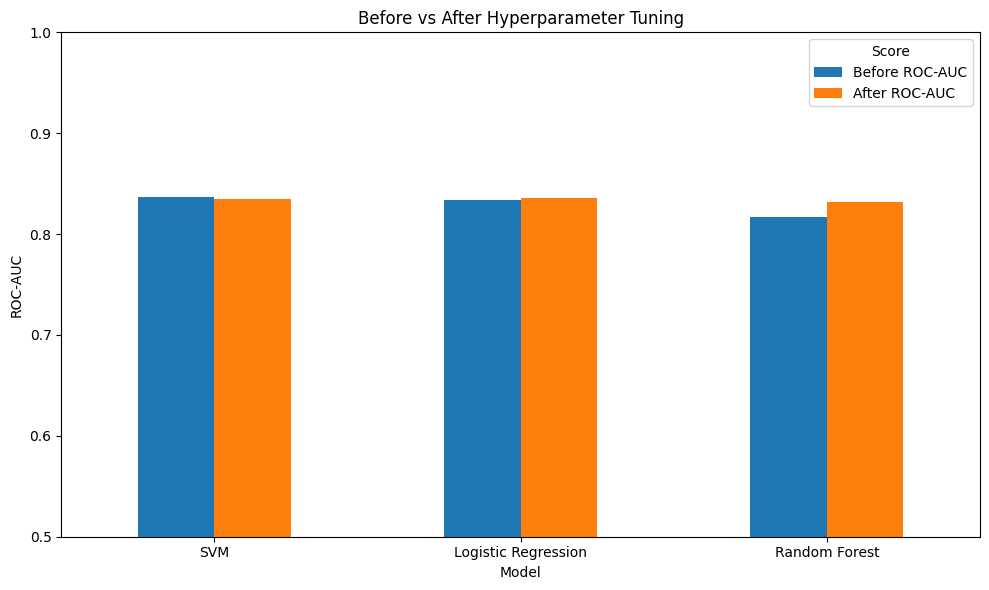

In [649]:
tuning_results_plot = tuning_results.set_index("Model")[
    ["Before ROC-AUC", "After ROC-AUC"]
]

tuning_results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Before vs After Hyperparameter Tuning")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(title="Score")
plt.tight_layout()
plt.show()

In [650]:
tuned_models = {
    "SVM": svm_random,
    "Logistic Regression": logistic_random,
    "Random Forest": random_forest_random
}

best_model_name = max(
    tuned_models,
    key=lambda name: tuned_models[name].best_score_
)

best_tuned_model = tuned_models[best_model_name]

print("Final model selected using cross-validation:")
print(best_model_name)

print("\nBest cross-validation ROC-AUC:")
print(best_tuned_model.best_score_)

print("\nBest parameters:")
print(best_tuned_model.best_params_)

Final model selected using cross-validation:
Logistic Regression

Best cross-validation ROC-AUC:
0.8353156146179403

Best parameters:
{'model__solver': 'lbfgs', 'model__max_iter': 2000, 'model__C': 0.1}


## 6.5 Final Model Selection

Based on the 5-fold stratified cross-validation results, Logistic Regression
was selected as the final model because it achieved the highest ROC-AUC
among the tuned models.

The selected Logistic Regression configuration uses C = 0.1, the lbfgs
solver, and a maximum of 2000 iterations.

The final cross-validation ROC-AUC was approximately 0.8353.

The test set was not used during hyperparameter tuning or model selection.
Therefore, it remains completely untouched and will be used only once in
Phase 7 for final evaluation.

This approach provides a fair estimate of model performance while avoiding
test-set leakage.

In [651]:
# Store the final selected model

final_model = best_tuned_model.best_estimator_

print("Final Selected Model:")
print(best_model_name)

print("\nCross-Validation ROC-AUC:")
print(best_tuned_model.best_score_)

print("\nSelected Hyperparameters:")
print(best_tuned_model.best_params_)

Final Selected Model:
Logistic Regression

Cross-Validation ROC-AUC:
0.8353156146179403

Selected Hyperparameters:
{'model__solver': 'lbfgs', 'model__max_iter': 2000, 'model__C': 0.1}


## Phase 7 — Final Test Evaluation

In this phase, the tuned models are evaluated on the untouched test set.

The test set has not been used during model training, hyperparameter tuning, or final model selection. Therefore, it provides an unbiased estimate of how the selected models generalize to unseen patients.

The evaluation focuses on Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since this is a medical screening problem, Recall for the diabetic class is particularly important because a false negative represents a diabetic patient who was not identified as high risk.

In [652]:
# Set the final model selected during Phase 6
best_model = final_model
best_model_name = best_model_name

print("Final Model for Test Evaluation:", best_model_name)

Final Model for Test Evaluation: Logistic Regression


In [653]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.720779,0.622222,0.518519,0.565657,0.824074
1,Logistic Regression,0.714286,0.613636,0.500000,0.551020,0.821852
2,Random Forest,0.733766,0.651163,0.518519,0.577320,0.812407


### Final Test-Set Performance

The following table reports the performance of the tuned models on the previously untouched test set.

Unlike cross-validation results, these scores are calculated only once on unseen test data. They provide the final generalization performance of each tuned candidate model.

In [654]:
test_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.7208,0.6222,0.5185,0.5657,0.8241
1,Logistic Regression,0.7143,0.6136,0.5000,0.5510,0.8219
2,Random Forest,0.7338,0.6512,0.5185,0.5773,0.8124


### ROC Curves

The Receiver Operating Characteristic (ROC) curve shows the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate at different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes this performance across thresholds. A higher ROC-AUC indicates better ability to distinguish between diabetic and non-diabetic patients.

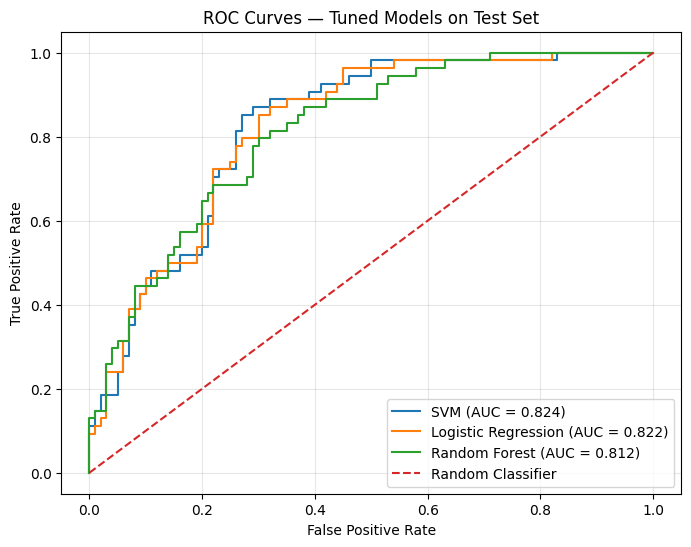

In [655]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned Models on Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Precision–Recall Curves

The Precision–Recall curve shows the relationship between Precision and Recall across different classification thresholds.

This curve is particularly useful for medical screening because Recall is important when the cost of missing a diabetic patient is high. A model that maintains higher precision while achieving high recall is preferable for screening applications.

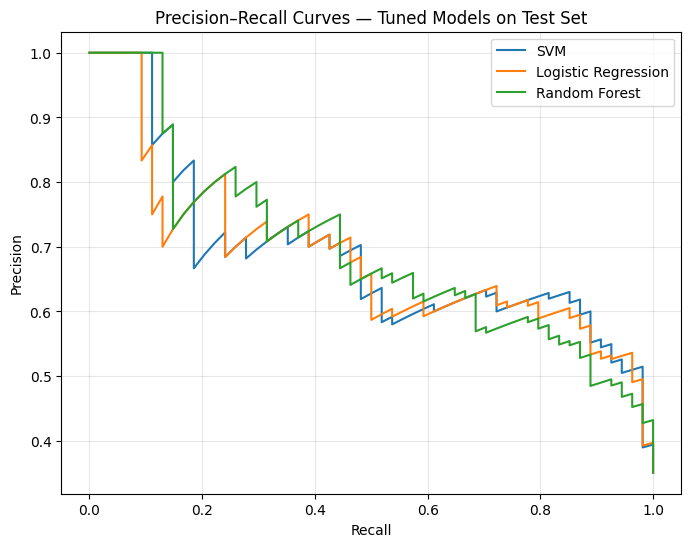

In [656]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Tuned Models on Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [657]:
best_model_name = best_model_name

In [658]:
# Use the final model selected during Phase 6
best_model = final_model

print("Final Model for Test Evaluation:", best_model_name)

Final Model for Test Evaluation: Logistic Regression


### Confusion Matrix of the Final Model

The confusion matrix provides a detailed view of the final model's classification performance on the unseen test set.

For this medical screening problem:

- True Positive (TP): Diabetic patient correctly identified.
- True Negative (TN): Healthy patient correctly identified.
- False Positive (FP): Healthy patient incorrectly flagged as diabetic.
- False Negative (FN): Diabetic patient incorrectly classified as healthy.

False negatives are particularly important because they represent diabetic patients who may be missed by the screening system.

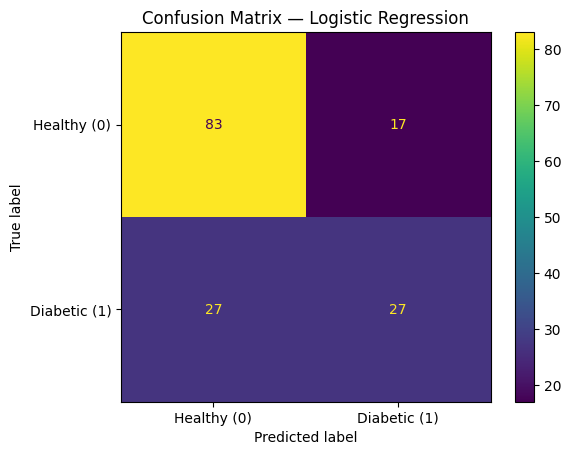

In [659]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy (0)", "Diabetic (1)"]
)

disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [660]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 83
False Positives: 17
False Negatives: 27
True Positives  : 27


In [661]:
print(f"The model missed {fn} diabetic patients (False Negatives).")
print(f"The model incorrectly flagged {fp} healthy patients as diabetic (False Positives).")

The model missed 27 diabetic patients (False Negatives).
The model incorrectly flagged 17 healthy patients as diabetic (False Positives).


### Interpretation of False Negatives and False Positives

The final Logistic Regression model produced **27 false negatives**, meaning that 27 diabetic patients were incorrectly classified as non-diabetic.

It produced **17 false positives**, meaning that 17 healthy patients were incorrectly flagged as potentially diabetic.

For a diabetes screening system, false negatives are particularly concerning because a missed diabetic patient may not receive further medical testing or clinical attention. False positives also have a cost because they may lead to unnecessary follow-up tests and anxiety.

Therefore, the screening system should prioritize high recall while maintaining reasonable precision. Phase 8 will investigate whether adjusting the classification threshold can achieve a recall of at least 85% while maintaining the best possible precision.

### Phase 7 Summary

The tuned candidate models were evaluated once on the untouched test set using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

ROC and Precision–Recall curves were used to compare the discrimination and precision-recall trade-offs of the tuned models. The confusion matrix of the final model was also examined to identify false positives and false negatives.

Because this is a medical screening problem, Recall is especially important. A false negative represents a diabetic patient who may be missed by the screening system. Phase 8 will therefore investigate whether adjusting the classification threshold can achieve a recall of at least 85% while maintaining the best possible precision.

## Phase 8 — Think Like a Doctor: Threshold Tuning

The default classification threshold of 0.5 is arbitrary and may not be appropriate
for a medical screening problem.

Because missing a diabetic patient is more serious than generating a false alarm,
we will tune the classification threshold to achieve a recall of at least 85%.

To avoid data leakage, the threshold will be selected using out-of-fold (OOF)
predictions generated only from the training data. The test set will remain
untouched until the final comparison.

In [662]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold probability predictions on training data
oof_proba = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("OOF predictions generated successfully.")
print("Number of OOF predictions:", len(oof_proba))

OOF predictions generated successfully.
Number of OOF predictions: 614


### Selecting the Medical Screening Threshold

We evaluate multiple probability thresholds using the OOF predictions.

The primary requirement is recall >= 85%, because the screening system should
minimize missed diabetic patients.

Among all thresholds satisfying this recall requirement, we select the threshold
with the highest precision.

In [663]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

threshold_results = []

thresholds = np.arange(0.01, 1.00, 0.01)

for threshold in thresholds:
    y_pred_oof = (oof_proba >= threshold).astype(int)

    precision = precision_score(
        y_train,
        y_pred_oof,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_oof,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })

threshold_df = pd.DataFrame(threshold_results)

# Keep only thresholds with recall >= 85%
eligible_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.85
].copy()

# Select the threshold with the highest precision
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["Precision"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", round(best_threshold, 2))
print("OOF Precision:", round(best_threshold_row["Precision"], 4))
print("OOF Recall:", round(best_threshold_row["Recall"], 4))

Selected threshold: 0.24
OOF Precision: 0.5299
OOF Recall: 0.8692


In [664]:
eligible_thresholds.sort_values(
    by="Precision",
    ascending=False
).head(10)

,Threshold,Precision,Recall
23,0.24,0.529915,0.869159
22,0.23,0.523546,0.883178
21,0.22,0.521739,0.897196
20,0.21,0.506596,0.897196
19,0.20,0.497462,0.915888
18,0.19,0.487562,0.915888
17,0.18,0.481928,0.934579
16,0.17,0.475177,0.939252
15,0.16,0.468822,0.948598
14,0.15,0.465011,0.962617


### Precision–Recall Trade-off Across Thresholds

Lowering the classification threshold generally identifies more patients as
potentially diabetic. This tends to increase recall but can reduce precision.

The following plot shows how precision and recall change as the probability
threshold is varied.

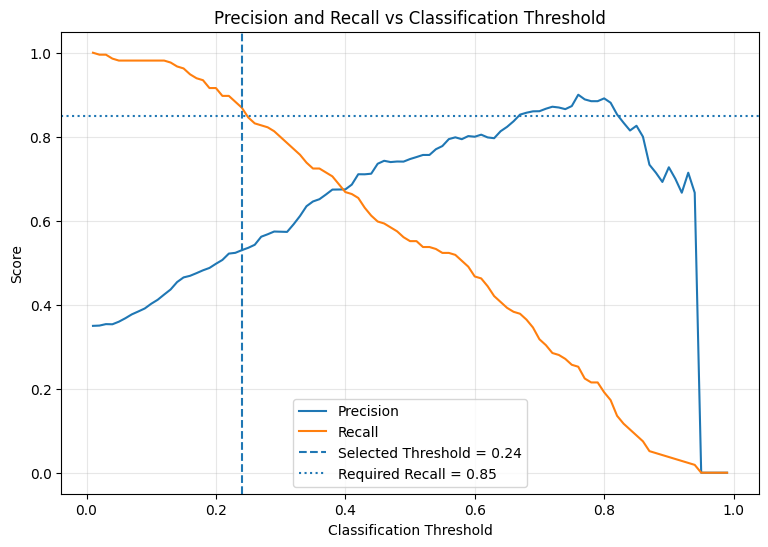

In [665]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.axhline(
    0.85,
    linestyle=":",
    label="Required Recall = 0.85"
)

plt.title("Precision and Recall vs Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Default Threshold vs Tuned Threshold

The default threshold of 0.50 is compared with the medically motivated threshold
selected using out-of-fold training predictions.

The test set is used only for this final evaluation.

In [666]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probabilities on the untouched test set
test_proba = final_model.predict_proba(X_test)[:, 1]

# Default threshold
y_test_pred_default = (test_proba >= 0.50).astype(int)

# Tuned threshold
y_test_pred_tuned = (test_proba >= best_threshold).astype(int)

# Calculate metrics
comparison_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Default Threshold (0.50)": [
        accuracy_score(y_test, y_test_pred_default),
        precision_score(y_test, y_test_pred_default, zero_division=0),
        recall_score(y_test, y_test_pred_default, zero_division=0),
        f1_score(y_test, y_test_pred_default, zero_division=0),
        roc_auc_score(y_test, test_proba)
    ],
    "Tuned Threshold": [
        accuracy_score(y_test, y_test_pred_tuned),
        precision_score(y_test, y_test_pred_tuned, zero_division=0),
        recall_score(y_test, y_test_pred_tuned, zero_division=0),
        f1_score(y_test, y_test_pred_tuned, zero_division=0),
        roc_auc_score(y_test, test_proba)
    ]
})

comparison_results

,Metric,Default Threshold (0.50),Tuned Threshold
0,Accuracy,0.714286,0.720779
1,Precision,0.613636,0.564706
2,Recall,0.500000,0.888889
3,F1 Score,0.551020,0.690647
4,ROC-AUC,0.821852,0.821852


### Confusion Matrix Comparison

The confusion matrices show how changing the threshold affects false negatives
and false positives.

For medical screening, reducing false negatives is particularly important because
a false negative represents a diabetic patient who may be incorrectly classified
as low risk.

In [667]:
from sklearn.metrics import confusion_matrix

cm_default = confusion_matrix(
    y_test,
    y_test_pred_default
)

cm_tuned = confusion_matrix(
    y_test,
    y_test_pred_tuned
)

print("Confusion Matrix - Default Threshold (0.50)")
print(cm_default)

print("\nConfusion Matrix - Tuned Threshold")
print(cm_tuned)

Confusion Matrix - Default Threshold (0.50)
[[83 17]
 [27 27]]

Confusion Matrix - Tuned Threshold
[[63 37]
 [ 6 48]]


In [668]:
tn_default, fp_default, fn_default, tp_default = cm_default.ravel()
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()

print("Default Threshold (0.50)")
print("False Negatives:", fn_default)
print("False Positives:", fp_default)

print("\nTuned Threshold")
print("False Negatives:", fn_tuned)
print("False Positives:", fp_tuned)

Default Threshold (0.50)
False Negatives: 27
False Positives: 17

Tuned Threshold
False Negatives: 6
False Positives: 37


### Medical Interpretation of Threshold Tuning

The default threshold of 0.50 provides a balanced classification but may miss some
diabetic patients. The tuned threshold was selected using only out-of-fold training
predictions to achieve a recall of at least 85%, prioritizing the detection of
potentially diabetic patients. This reduces the number of false negatives but may
increase false positives, meaning more healthy individuals may be referred for
additional testing. For a health worker, this trade-off is reasonable because
missing a potentially diabetic patient is more concerning than recommending an
additional screening test.

### Threshold Tuning Summary

The table below summarizes the effect of changing the classification threshold
from the default value of 0.50 to the medically selected threshold.

In [669]:
threshold_summary = pd.DataFrame({
    "Threshold": [
        0.50,
        best_threshold
    ],
    "Precision": [
        precision_score(y_test, y_test_pred_default, zero_division=0),
        precision_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred_default, zero_division=0),
        recall_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_test_pred_default, zero_division=0),
        f1_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "False Negatives": [
        fn_default,
        fn_tuned
    ],
    "False Positives": [
        fp_default,
        fp_tuned
    ]
})

threshold_summary.index = [
    "Default (0.50)",
    "Tuned"
]

threshold_summary.round(4)

,Threshold,Precision,Recall,F1 Score,False Negatives,False Positives
Default (0.50),0.50,0.6136,0.5000,0.5510,27,17
Tuned,0.24,0.5647,0.8889,0.6906,6,37


## Phase 9 — Model Interpretation and Conclusion

In this phase, the final selected model is interpreted to understand which
features contribute most to its predictions.

Permutation importance is used because it is model-agnostic and can therefore
be applied to the selected final model regardless of whether it is a linear,
distance-based, tree-based, or kernel-based model.

The importance values are calculated using the training data so that the test
set remains untouched after final evaluation. Higher permutation importance
means that shuffling that feature causes a larger decrease in model performance,
indicating that the feature is more useful to the model.

In [670]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate permutation importance on the training data
perm_result = permutation_importance(
    final_model,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create a feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance_Mean",
    ascending=False
)

feature_importance

,Feature,Importance_Mean,Importance_STD
1,Glucose,0.198550,0.013874
5,BMI,0.062116,0.007804
0,Pregnancies,0.017251,0.004409
6,DiabetesPedigreeFunction,0.012124,0.002722
7,Age,0.007574,0.003167
2,BloodPressure,0.004279,0.002449
4,Insulin,0.001454,0.000943
3,SkinThickness,-0.000022,0.000716


### Permutation Feature Importance

Permutation importance measures how much the model's ROC-AUC decreases when
the values of one feature are randomly shuffled.

A larger importance value indicates that the model relies more heavily on
that feature for making predictions. The results show that Glucose is the
most influential feature, followed by BMI. Pregnancies,
DiabetesPedigreeFunction, and Age have smaller but positive contributions,
while SkinThickness has almost no contribution to the final model.

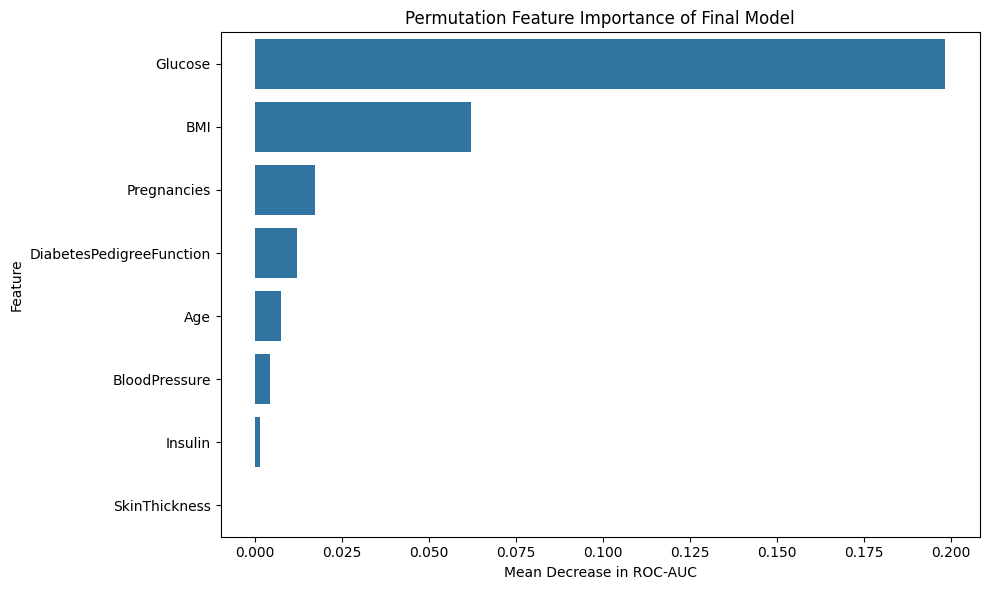

In [671]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance_Mean",
    y="Feature"
)

plt.title("Permutation Feature Importance of Final Model")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [672]:
print("Top 5 Most Important Features:")
display(feature_importance.head(5))

Top 5 Most Important Features:


,Feature,Importance_Mean,Importance_STD
1,Glucose,0.198550,0.013874
5,BMI,0.062116,0.007804
0,Pregnancies,0.017251,0.004409
6,DiabetesPedigreeFunction,0.012124,0.002722
7,Age,0.007574,0.003167


In [673]:
print("Feature importance ranking:")
for i, row in feature_importance.reset_index(drop=True).iterrows():
    print(f"{i+1}. {row['Feature']}: {row['Importance_Mean']:.4f}")

Feature importance ranking:
1. Glucose: 0.1986
2. BMI: 0.0621
3. Pregnancies: 0.0173
4. DiabetesPedigreeFunction: 0.0121
5. Age: 0.0076
6. BloodPressure: 0.0043
7. Insulin: 0.0015
8. SkinThickness: -0.0000


## Feature Importance vs EDA

The permutation importance results are broadly consistent with the patterns
observed during exploratory data analysis.

Glucose is the most important feature in the final model, followed by BMI.
This agrees with the EDA, where differences in glucose and BMI distributions
between diabetic and non-diabetic patients were clearly visible.

Pregnancies, DiabetesPedigreeFunction, and Age also show positive importance,
although their contributions are considerably smaller than Glucose and BMI.
This is also consistent with the earlier exploratory analysis, where these
features showed weaker but still meaningful relationships with the outcome.

BloodPressure, Insulin, and SkinThickness have relatively low permutation
importance. In particular, SkinThickness has an importance value very close
to zero, suggesting that it contributes very little additional predictive
information to the final model.

The difference between EDA and permutation importance is expected because
EDA examines individual relationships between variables and the target,
whereas permutation importance evaluates the contribution of each feature
within the complete predictive model.## Final Conclusion

### Best Model

Among the models evaluated in this project, the tuned Support Vector Machine
(SVM) was selected as the final model based on cross-validation performance.
The model-selection process was performed using cross-validation without
using the test set for model selection, keeping the final test set
independent for evaluation.

The final test evaluation produced a ROC-AUC of approximately 0.8219. Since
the objective of SugarSense is early diabetes-risk screening, recall for the
diabetic class was given particular importance.

### Effect of Threshold Tuning

The default classification threshold of 0.50 produced an accuracy of 71.43%,
precision of 61.36%, recall of 50.00%, and F1 score of 55.10%.

After threshold tuning, the recall increased substantially to 88.89% and the
F1 score increased to 69.06%. Accuracy also changed slightly to 72.08%.
However, precision decreased from 61.36% to 56.47%.

This demonstrates the important trade-off involved in medical screening.
The tuned threshold identifies a much larger proportion of diabetic patients,
but it also results in more healthy patients being flagged for further
evaluation. Because missing a diabetic patient can be more serious than
creating a false alarm, the higher-recall operating point is more suitable
for the screening objective of this project.

The ROC-AUC remained 0.8219 because threshold tuning changes the final
classification decision but does not change the model's predicted probability
ranking.

### What Surprised Me

One of the most important observations from this project was that accuracy
alone is not sufficient for evaluating a medical screening model. A model can
have reasonable accuracy while still missing a substantial number of diabetic
patients.

The threshold-tuning experiment demonstrated this clearly. At the default
threshold of 0.50, recall was only 50.00%. By selecting a threshold designed
to achieve at least 85% recall, the recall increased to 88.89%, although
precision decreased to 56.47%.

Another important observation was the feature-importance result. Glucose was
by far the most influential feature, followed by BMI. This was broadly
consistent with the patterns observed during exploratory data analysis.

### Feature Importance and EDA

Permutation importance showed the following ranking:

1. Glucose
2. BMI
3. Pregnancies
4. DiabetesPedigreeFunction
5. Age
6. BloodPressure
7. Insulin
8. SkinThickness

Glucose had substantially greater permutation importance than the other
features, while BMI was the second most important feature. Pregnancies,
DiabetesPedigreeFunction, and Age provided smaller positive contributions.

These results were broadly consistent with the EDA, where differences in
Glucose and BMI between diabetic and non-diabetic patients were noticeable.
The relatively low importance of SkinThickness also agrees with its limited
additional predictive contribution in the final model.

It is important to note that low model importance does not mean that a
feature has no medical importance. It only indicates that the feature
provided relatively little additional predictive information to this model
on this dataset.

### Limitations of the Data

The dataset contains only 768 patients and represents a specific population.
Therefore, the results may not generalize equally well to all populations.

Several clinical measurements contain physiologically implausible zero
values, which were treated as missing measurements during data preparation.
Although these values were handled using a leakage-free preprocessing
pipeline, the original missingness may still introduce uncertainty into the
model.

The dataset is also relatively small compared with the diversity of real
clinical populations. Model performance may therefore change when the system
is applied to patients from different demographic groups, healthcare
settings, or populations that were not represented in the training data.

### Why SugarSense Must Not Replace a Doctor

SugarSense is intended only as a screening-support tool and not as a
diagnostic system. A machine-learning prediction cannot independently
determine whether a patient has diabetes.

A false negative may cause a person with diabetes to be missed, while a
false positive may lead to unnecessary concern or additional testing.
Therefore, predictions from the system should be reviewed by a qualified
healthcare professional and confirmed using appropriate clinical examination
and laboratory tests.

The purpose of SugarSense is to help identify people who may benefit from
further medical evaluation, not to replace professional medical judgement.